# Explore here

In [10]:
# Goal 1: Find predictors for price outcomes

In [5]:
# Your code here
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
main_df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")
main_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
drop_list = ['name', 'id', 'host_name', 'host_id', ]
include_list = ['room_type', 'neighbourhood_group', 'price']

In [8]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

<Axes: xlabel='latitude', ylabel='longitude'>

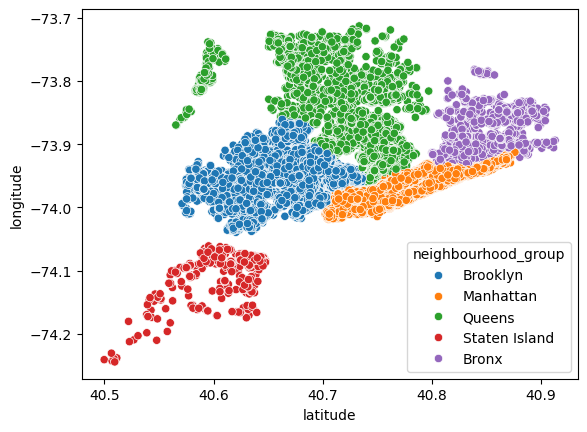

In [27]:
sns.scatterplot(main_df, x = 'latitude', y='longitude', hue = 'neighbourhood_group')

<Axes: xlabel='id', ylabel='price'>

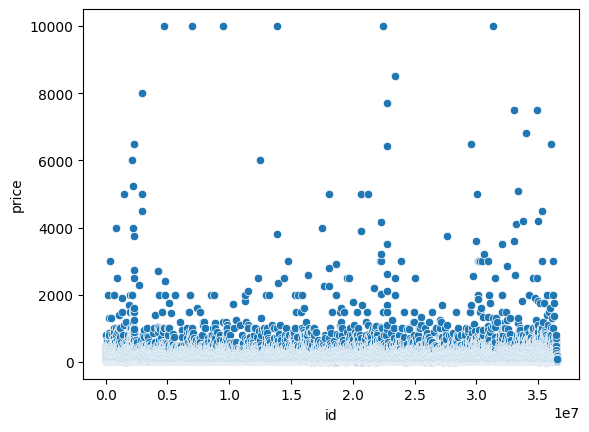

In [13]:
#does id seem to be relvant as a predictor: no
sns.scatterplot(data= main_df, x='id', y='price')

In [14]:
main_df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [16]:
main_df.groupby('room_type')['price'].mean()

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

In [ ]:
sns.kdeplot(data=main_df[main_df[minimum_night < 50], x=minimum_types, hue='room_type            9o0000000'])

Feature Engineering

In [19]:
def short_long_stay(x):
    if x >= 31:
        return "long"
    elif x <=31:
        return "short"
    else:
        return "unknown"

In [20]:
main_df["stay"] = main_df['minimum_nights'].apply(short_long_stay)

In [22]:
main_df.groupby('stay')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
stay,,,,,,,,
long,747.0,238.863454,686.472801,12.0,75.0,120.0,195.5,10000.0
short,48148.0,151.384211,226.164432,0.0,69.0,105.0,175.0,10000.0


<Axes: xlabel='price'>

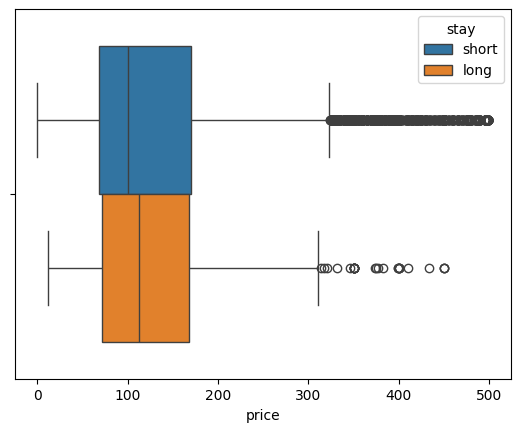

In [39]:
sns.boxplot(data=main_df[main_df['price'] < 500], x='price', hue='stay')

In [28]:
include_list = ['room_type', 'neighbourhood_group', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'stay']
X = main_df[include_list]
y = main_df['price']

In [33]:
X_dummies = pd.get_dummies(X, dtype='int', drop_first=True)

In [34]:
X_dummies.isna().sum()

minimum_nights                           0
number_of_reviews                        0
reviews_per_month                    10052
room_type_Private room                   0
room_type_Shared room                    0
neighbourhood_group_Brooklyn             0
neighbourhood_group_Manhattan            0
neighbourhood_group_Queens               0
neighbourhood_group_Staten Island        0
stay_short                               0
dtype: int64

In [35]:
X_dummies = X_dummies.fillna(0)

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y)

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
my_test_preds = linreg_model.predict(X_test)

In [44]:
from sklearn.metrics import mean_squared_error

In [ ]:
np.sqrt(mean_squared_error(y_true = y_test, y_pred = my_test_preds))
# about how off the predictions were

np.float64(225.31720104412346)

In [ ]:
#should have removed outliers 